Análisis de la Industria de Videojuegos (1980 - 2020)

In [1]:
#instala pandas
pip install pandas

SyntaxError: invalid syntax (1134559820.py, line 2)

In [2]:
#Importo librerias

import pandas as pd 

import numpy as np

# Carga el dataset

df = pd.read_csv("/workspaces/proyecto-final-videojuegos-/data/vgsales.csv")



In [3]:
# analiza registros y columnas reales
df.shape

(16598, 11)

In [4]:
#contemplo el df
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
#Reviso los tipos de datos 
df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [6]:
# chequeamos los nulos

df.isnull()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
16593,False,False,False,False,False,False,False,False,False,False,False
16594,False,False,False,False,False,False,False,False,False,False,False
16595,False,False,False,False,False,False,False,False,False,False,False
16596,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [8]:
# Creo Copia de seguridad

df_limpio = df.copy()

In [9]:
# tome la desicion de eliminal las filas donde el año es nulo 
#ya que son (271 nulos - 1.6% de los datos) Como representan apenas 
# el 1.6% de todo el volumen de datos, perderlas no va a 
#  distorsionar nuestras conclusiones estadísticas sobre el mercado global

df_limpio = df.dropna(subset=["Year"]).copy()

#relleno los nulos 

df_limpio["Publisher"] = df_limpio["Publisher"].fillna("Sin datos")

# conversion de años a tipo int

df_limpio["Year"] = df_limpio["Year"].astype(int)


In [10]:
#verificacion

df_limpio.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [11]:
print(f"\nFilas originales: {len(df)} | Filas después de la limpieza: {len(df_limpio)}")
print(f"Porcentaje de datos conservados: {len(df_limpio) / len(df) * 100:.2f}%")


Filas originales: 16598 | Filas después de la limpieza: 16327
Porcentaje de datos conservados: 98.37%


In [12]:
pip install matplotlib



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


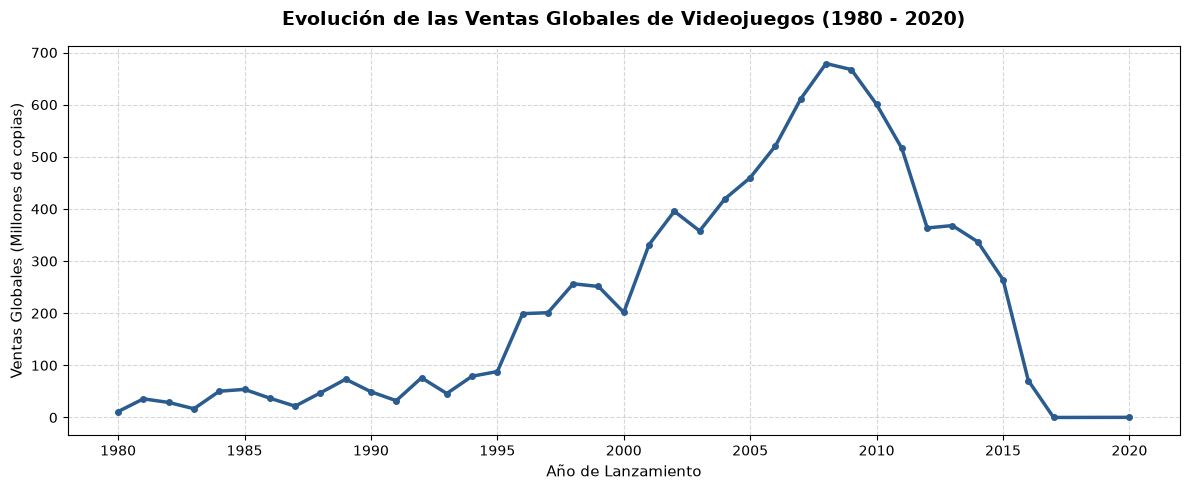

In [14]:
#Analicis evaulacion de ventas por año
import matplotlib.pyplot as plt
import seaborn as sns

#agrupo por año
ventas_por_anio = df_limpio.groupby("Year")["Global_Sales"].sum().reset_index()

#grafico de tendencia temporal

plt.figure(figsize=(12, 5))
plt.plot(ventas_por_anio["Year"], ventas_por_anio["Global_Sales"], color="#2b5c8f", linewidth=2.5, marker="o", markersize=4)

plt.title("Evolución de las Ventas Globales de Videojuegos (1980 - 2020)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Año de Lanzamiento", fontsize=11)
plt.ylabel("Ventas Globales (Millones de copias)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

/tmp/ipykernel_7413/3504305718.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_na, x="NA_Sales", y="Genero_Es", palette="Blues_r", ax=ax1)
/tmp/ipykernel_7413/3504305718.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_jp, x="JP_Sales", y="Genero_Es", palette="Oranges_r", ax=ax2)


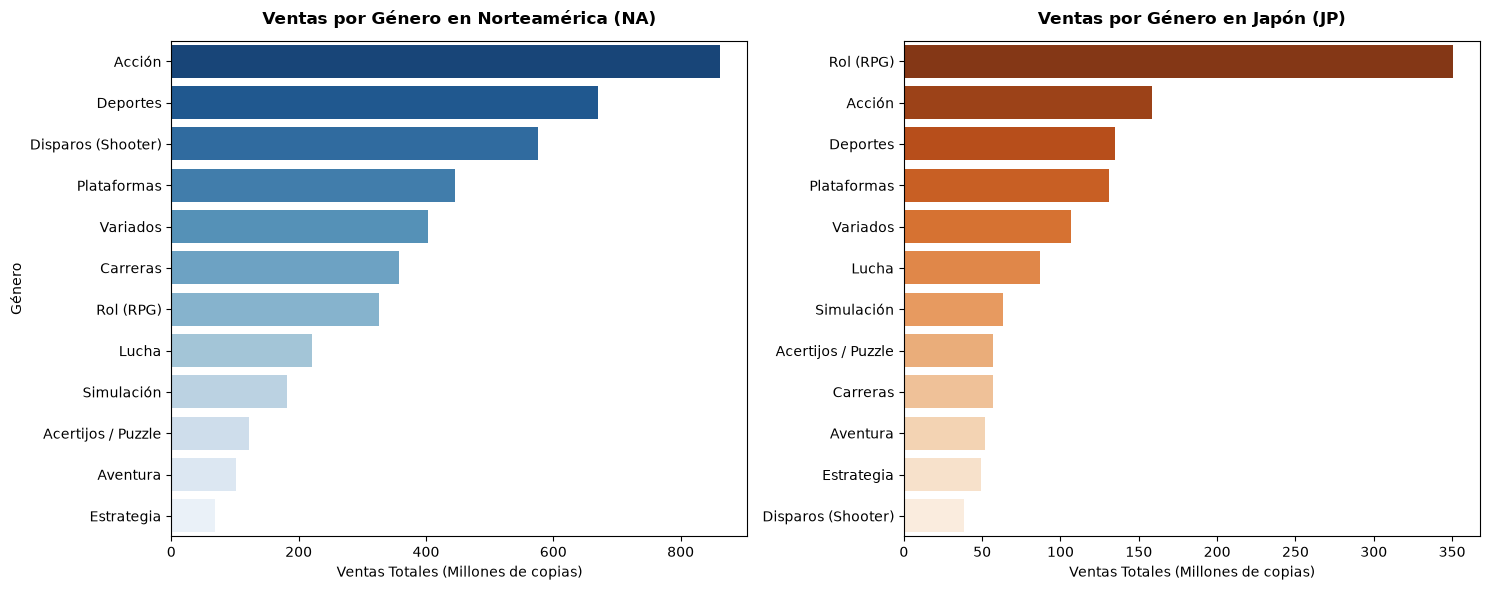

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#  traduzco a español
dicc_generos = {
    "Action": "Acción",
    "Sports": "Deportes",
    "Shooter": "Disparos (Shooter)",
    "Role-Playing": "Rol (RPG)",
    "Platform": "Plataformas",
    "Misc": "Variados",
    "Racing": "Carreras",
    "Fighting": "Lucha",
    "Simulation": "Simulación",
    "Puzzle": "Acertijos / Puzzle",
    "Adventure": "Aventura",
    "Strategy": "Estrategia"
}

# creao una nueva columna con los géneros traducidos
df_limpio["Genero_Es"] = df_limpio["Genre"].map(dicc_generos).fillna(df_limpio["Genre"])

# agrupo las ventas por género en español
generos_region = df_limpio.groupby("Genero_Es")[["NA_Sales", "JP_Sales"]].sum().reset_index()

# ordeno de mayor a menor para Norteamérica y Japón
top_na = generos_region.sort_values(by="NA_Sales", ascending=False)
top_jp = generos_region.sort_values(by="JP_Sales", ascending=False)

# ahora si graficos 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: NORTEAMÉRICA
sns.barplot(data=top_na, x="NA_Sales", y="Genero_Es", palette="Blues_r", ax=ax1)
ax1.set_title("Ventas por Género en Norteamérica (NA)", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Ventas Totales (Millones de copias)", fontsize=10)
ax1.set_ylabel("Género", fontsize=10)

# GRÁFICO 2: JAPÓN 
sns.barplot(data=top_jp, x="JP_Sales", y="Genero_Es", palette="Oranges_r", ax=ax2)
ax2.set_title("Ventas por Género en Japón (JP)", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Ventas Totales (Millones de copias)", fontsize=10)
ax2.set_ylabel("", fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7413/2535371488.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_empresa, x="Empresa", y="Global_Sales", palette="Blues_r", ax=ax)


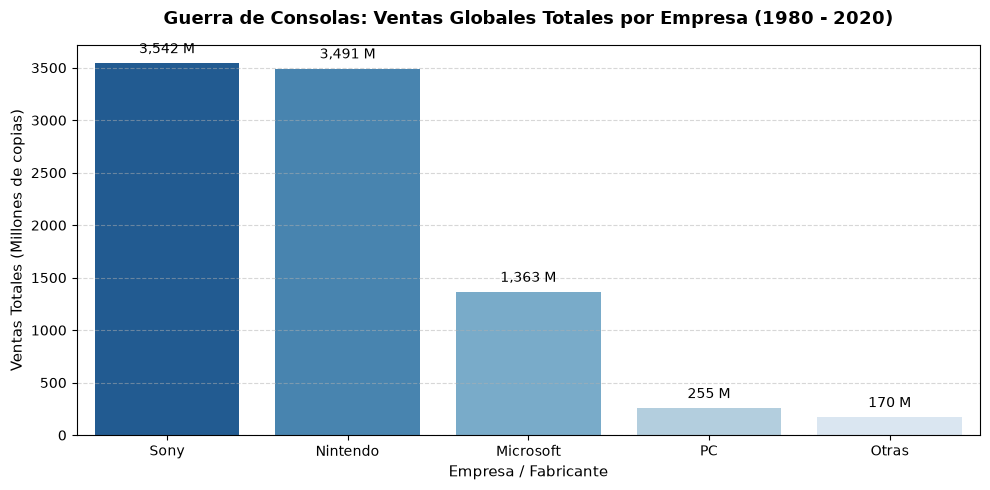

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Creo un mapeo para agrupar las consolas por su empresa fabricante
empresa_map = {
    'PS': 'Sony', 'PS2': 'Sony', 'PS3': 'Sony', 'PS4': 'Sony', 'PSP': 'Sony', 'PSV': 'Sony',
    'DS': 'Nintendo', 'Wii': 'Nintendo', 'GBA': 'Nintendo', 'GB': 'Nintendo', 
    '3DS': 'Nintendo', 'NES': 'Nintendo', 'N64': 'Nintendo', 'SNES': 'Nintendo', 
    'GC': 'Nintendo', 'WiiU': 'Nintendo',
    'X360': 'Microsoft', 'XB': 'Microsoft', 'XOne': 'Microsoft',
    'PC': 'PC'
}

# asigno la columna 'Empresa' (las consolas antiguas o menores quedan en 'Otras')
df_limpio["Empresa"] = df_limpio["Platform"].map(empresa_map).fillna("Otras")

# agrupo las ventas globales totales por empresa
ventas_empresa = df_limpio.groupby("Empresa")["Global_Sales"].sum().reset_index()
ventas_empresa = ventas_empresa.sort_values(by="Global_Sales", ascending=False)

# Creamos el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ventas_empresa, x="Empresa", y="Global_Sales", palette="Blues_r", ax=ax)

ax.set_title("Guerra de Consolas: Ventas Globales Totales por Empresa (1980 - 2020)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Empresa / Fabricante", fontsize=11)
ax.set_ylabel("Ventas Totales (Millones de copias)", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# añado los valores exactos arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} M', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()